In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Add the strategies folder to Python's search path, so we can import
# functions from signal.py without duplicating any code here
sys.path.append(os.path.abspath("../strategies/mean_reversion_bb"))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from signal_bt import get_db_engine, load_price_data, generate_signals

In [2]:
engine = get_db_engine()
price_df = load_price_data(engine, symbol="NIFTYBEES")

lookback = 20
num_std = 2.0

rolling_mean = price_df['close'].rolling(lookback).mean()
rolling_std = price_df['close'].rolling(lookback).std()
upper_band = rolling_mean + (num_std * rolling_std)
lower_band = rolling_mean - (num_std * rolling_std)

signals = generate_signals(price_df, lookback=lookback, num_std=num_std)

print(f"Loaded {len(price_df)} rows, {len(signals[signals != 0])} signal events")

Loaded 1874 rows, 229 signal events


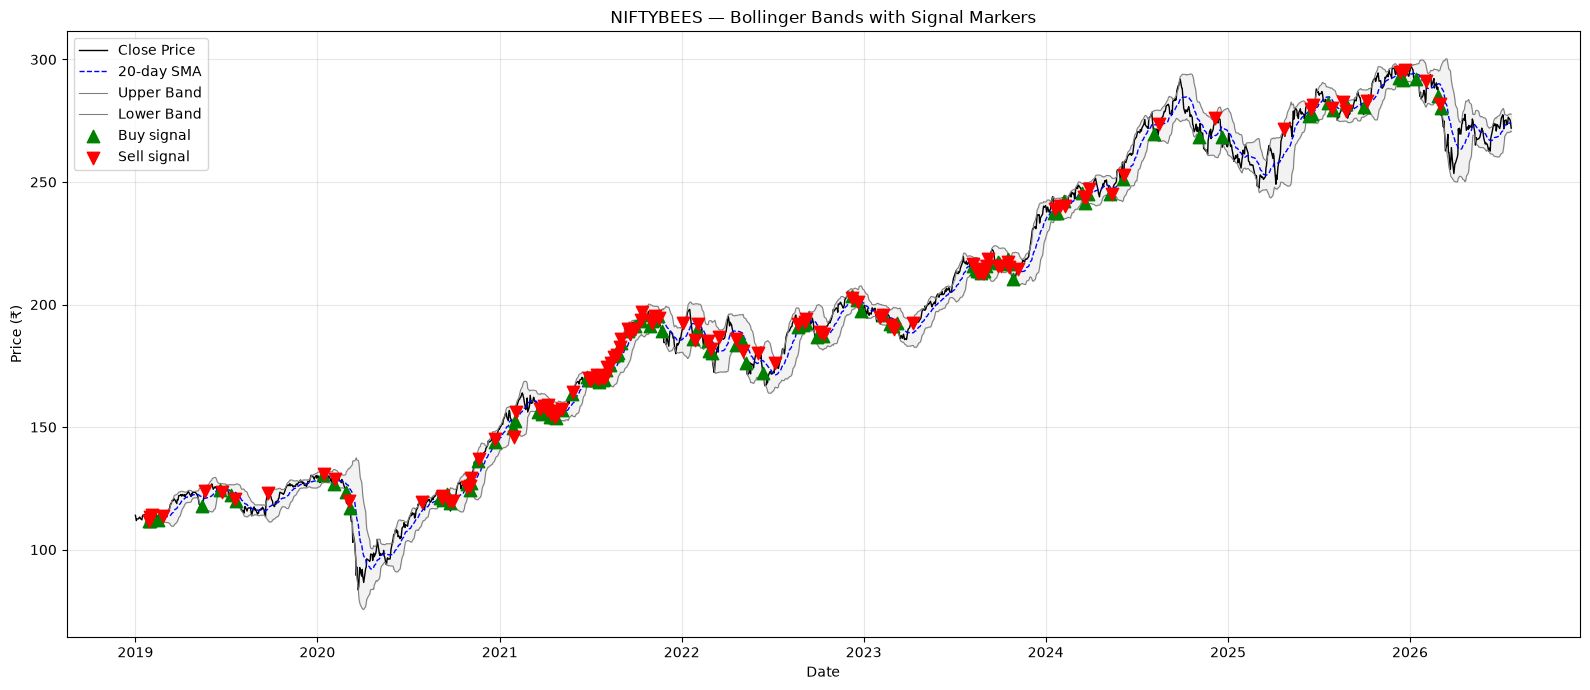

In [3]:
fig, ax = plt.subplots(figsize=(16, 7))

# Price and bands
ax.plot(price_df.index, price_df['close'], label='Close Price', color='black', linewidth=1)
ax.plot(price_df.index, rolling_mean, label=f'{lookback}-day SMA', color='blue', linewidth=1, linestyle='--')
ax.plot(price_df.index, upper_band, label='Upper Band', color='gray', linewidth=0.8)
ax.plot(price_df.index, lower_band, label='Lower Band', color='gray', linewidth=0.8)

# Shade the area between the bands, so the "channel" is visually obvious
ax.fill_between(price_df.index, lower_band, upper_band, color='gray', alpha=0.1)

# Mark entry (+1) and exit (-1) points directly on the price line
entries = price_df.index[signals == 1]
exits = price_df.index[signals == -1]

ax.scatter(entries, price_df.loc[entries, 'close'], color='green', marker='^', s=80, label='Buy signal', zorder=5)
ax.scatter(exits, price_df.loc[exits, 'close'], color='red', marker='v', s=80, label='Sell signal', zorder=5)

ax.set_title('NIFTYBEES — Bollinger Bands with Signal Markers')
ax.set_xlabel('Date')
ax.set_ylabel('Price (₹)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Reuse the CSV already saved by run_universe_scan(), rather than
# re-running the scan (which takes several minutes across ~3,700 symbols)
results_path = os.path.abspath("../strategies/mean_reversion_bb/universe_scan_results.csv")
results_df = pd.read_csv(results_path)

print(f"Loaded {len(results_df)} symbols")
print(results_df.head())

Loaded 2898 symbols
         symbol  num_trades      total_pnl  avg_pnl_per_trade  \
0       ARIHANT          19  229552.084067       12081.688635   
1    KKVAPOW-SM           1    6421.692854        6421.692854   
2       DIRL-SM           2    9331.530860        4665.765430   
3    JETKNIT-ST           2    8903.618840        4451.809420   
4  BLUECOAST-BE           1    4034.749035        4034.749035   

  first_entry_date last_exit_date  years_active    cagr_pct  
0       2020-06-12     2026-07-17      6.094456   68.397970  
1       2023-08-02     2024-01-29      0.492813  173.601751  
2       2022-02-10     2025-02-01      2.976044   24.792993  
3       2019-05-24     2023-08-28      4.262834   16.111037  
4       2025-04-04     2025-07-29      0.317591  190.739675  


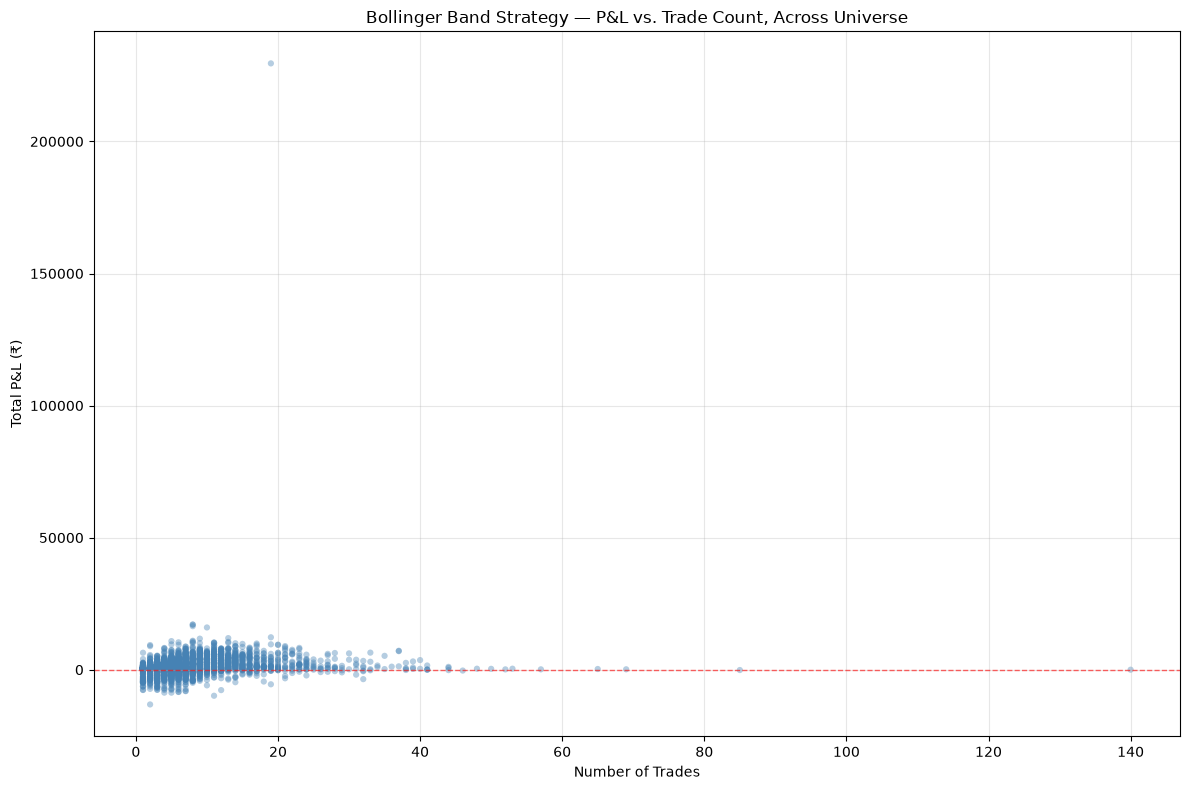

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    results_df["num_trades"],
    results_df["total_pnl"],
    alpha=0.4,
    s=20,
    color="steelblue",
    edgecolors="none",
)

# A horizontal line at zero P&L makes it immediately obvious which
# stocks were profitable vs. losing, at a glance
ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.6)

ax.set_xlabel("Number of Trades")
ax.set_ylabel("Total P&L (₹)")
ax.set_title("Bollinger Band Strategy — P&L vs. Trade Count, Across Universe")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
FIXED_INVESTMENT = 10000  # must match whatever value run_universe_scan() used when this CSV was generated

# Reading dates back from a CSV always gives you plain strings, not real
# datetime objects — even though they started as actual Timestamps when
# this DataFrame was first built. Converting them back is necessary before
# we can do date math (.min(), .max(), formatting) on them.
results_df["first_entry_date"] = pd.to_datetime(results_df["first_entry_date"])
results_df["last_exit_date"] = pd.to_datetime(results_df["last_exit_date"])


# --- Step 1: convert total_pnl into a percentage return ---
# Recall: total_pnl for each stock = sum of (fixed_investment * pct_return)
# across all its trades. Dividing back out by fixed_investment recovers the
# SUM of per-trade percentage returns — a figure no longer tied to the
# arbitrary ₹10,000 assumption, and directly comparable across stocks
# regardless of their actual price level.
results_df["total_pnl_pct"] = (results_df["total_pnl"] / FIXED_INVESTMENT) * 100

# --- Step 2: remove extreme outliers using the IQR method ---
# IQR = Interquartile Range = the spread between the 25th and 75th
# percentile of the data. Anything more than 1.5x that spread beyond
# either edge is a standard, widely-used statistical convention for
# flagging outliers — not something specific to trading, just a common
# general-purpose rule of thumb.
q1 = results_df["total_pnl_pct"].quantile(0.25)
q3 = results_df["total_pnl_pct"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

filtered_df = results_df[
    (results_df["total_pnl_pct"] >= lower_bound) &
    (results_df["total_pnl_pct"] <= upper_bound)
].copy()

print(f"Removed {len(results_df) - len(filtered_df)} outliers "
      f"(kept {len(filtered_df)} of {len(results_df)} symbols)")
print(f"Outlier bounds: {lower_bound:.1f}% to {upper_bound:.1f}%")

# --- Step 3: figure out the overall timeline actually covered ---
timeline_start = results_df["first_entry_date"].min().date()
timeline_end = results_df["last_exit_date"].max().date()
print(f"Timeline: {timeline_start} to {timeline_end}")

Removed 150 outliers (kept 2748 of 2898 symbols)
Outlier bounds: -44.9% to 77.7%
Timeline: 2019-05-24 to 2026-07-23


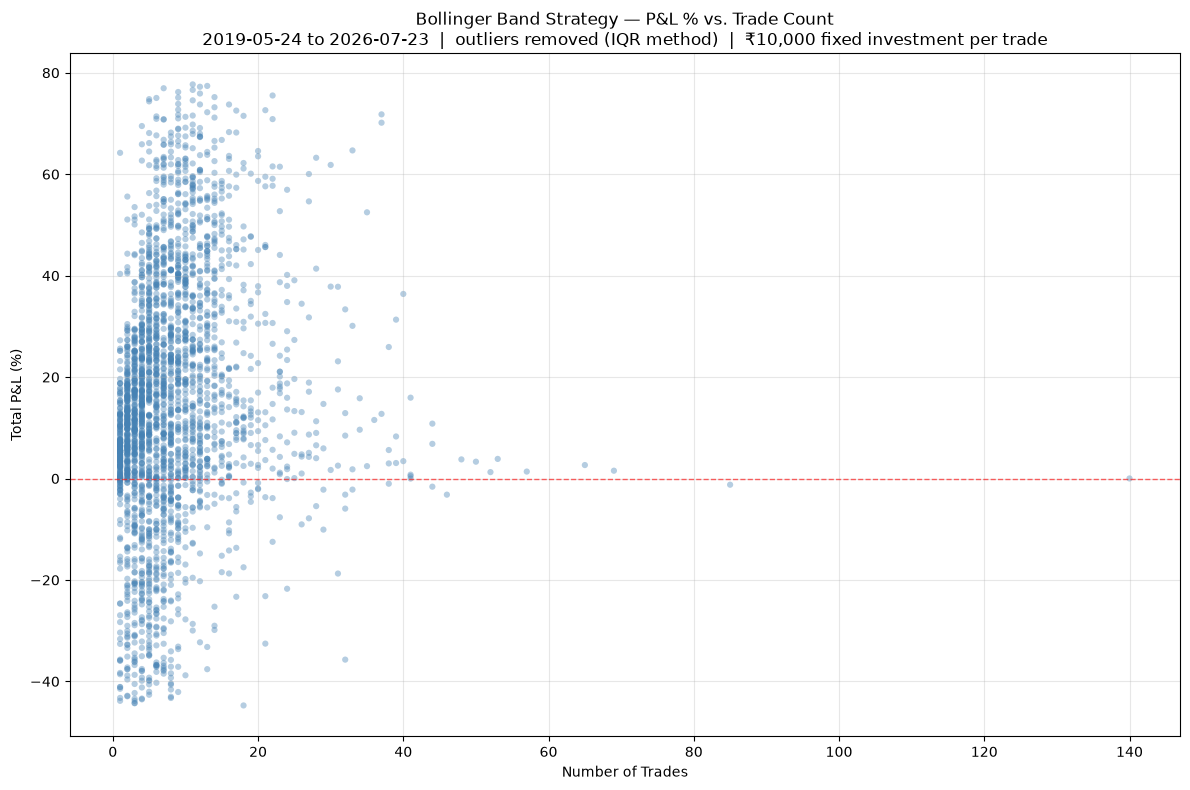

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    filtered_df["num_trades"],
    filtered_df["total_pnl_pct"],
    alpha=0.4,
    s=20,
    color="steelblue",
    edgecolors="none",
)

ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.6)

ax.set_xlabel("Number of Trades")
ax.set_ylabel("Total P&L (%)")
ax.set_title(
    f"Bollinger Band Strategy — P&L % vs. Trade Count\n"
    f"{timeline_start} to {timeline_end}  |  outliers removed (IQR method)  |  "
    f"₹{FIXED_INVESTMENT:,} fixed investment per trade"
)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Kept 289 of 2748 symbols with more than 15 trades and a valid CAGR


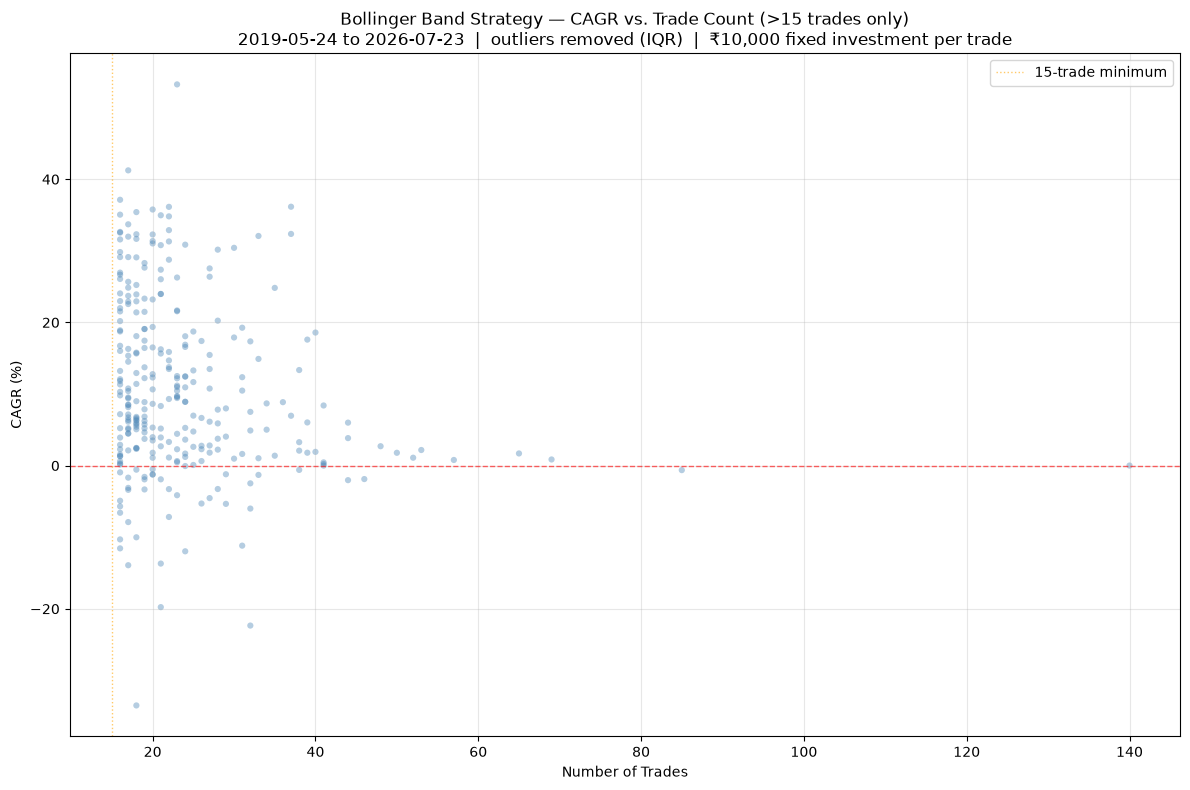

In [9]:
min_trades = 15
plot_df = filtered_df[filtered_df["num_trades"] > min_trades].copy()

# CAGR is undefined for some symbols (too-short time span, or a total
# wipeout) — dropna removes those rather than letting a NaN silently
# break or distort the plot
plot_df = plot_df.dropna(subset=["cagr_pct"])

print(f"Kept {len(plot_df)} of {len(filtered_df)} symbols with more than {min_trades} trades "
      f"and a valid CAGR")

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    plot_df["num_trades"],
    plot_df["cagr_pct"],
    alpha=0.4,
    s=20,
    color="steelblue",
    edgecolors="none",
)

ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(min_trades, color="orange", linestyle=":", linewidth=1, alpha=0.6,
           label=f"{min_trades}-trade minimum")

ax.set_xlabel("Number of Trades")
ax.set_ylabel("CAGR (%)")
ax.set_title(
    f"Bollinger Band Strategy — CAGR vs. Trade Count (>{min_trades} trades only)\n"
    f"{timeline_start} to {timeline_end}  |  outliers removed (IQR)  |  "
    f"₹{FIXED_INVESTMENT:,} fixed investment per trade"
)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()